# Part-1: Demonstration

## Model Selection Using Best Subset Selection and Cross-Validation

In this assignment, you will apply **Best Subset Selection** to the `Hitters` dataset from the `ISLR` package using the `regsubsets()` function from the `leaps` package. You will evaluate competing linear regression models using multiple model selection criteria and compare training-based metrics with cross-validation results.

You are expected to write clean, reproducible code and provide clear statistical interpretation of your findings.

## Dataset

You will work with the **Hitters** dataset from the `ISLR` package.

* Response variable: `Salary`
* Predictors: All remaining variables
* Missing values: You must properly handle missing data before fitting models.

In [3]:
library(ISLR)
library(leaps)
library(tidyverse)
library(caret)
library(knitr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




In [4]:
# GET DATA
data(Hitters)

# EXPLORE DATA
head(Hitters)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<dbl>,<fct>
-Andy Allanson,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NA,A
-Alan Ashby,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
-Alvin Davis,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
-Andre Dawson,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
-Andres Galarraga,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [12]:
# EXPLORE MORE
dim(Hitters)
class(Hitters)
colnames(Hitters)


[1] 322  20

[1] "data.frame"

[1] "AtBat"     "Hits"      "HmRun"     "Runs"      "RBI"       "Walks"    
 [7] "Years"     "CAtBat"    "CHits"     "CHmRun"    "CRuns"     "CRBI"     
[13] "CWalks"    "League"    "Division"  "PutOuts"   "Assists"   "Errors"   
[19] "Salary"    "NewLeague"

In [5]:
# STATISTICAL SUMMARY
summary(Hitters)

     AtBat            Hits         HmRun            Runs       
 Min.   : 16.0   Min.   :  1   Min.   : 0.00   Min.   :  0.00  
 1st Qu.:255.2   1st Qu.: 64   1st Qu.: 4.00   1st Qu.: 30.25  
 Median :379.5   Median : 96   Median : 8.00   Median : 48.00  
 Mean   :380.9   Mean   :101   Mean   :10.77   Mean   : 50.91  
 3rd Qu.:512.0   3rd Qu.:137   3rd Qu.:16.00   3rd Qu.: 69.00  
 Max.   :687.0   Max.   :238   Max.   :40.00   Max.   :130.00  
                                                               
      RBI             Walks            Years            CAtBat       
 Min.   :  0.00   Min.   :  0.00   Min.   : 1.000   Min.   :   19.0  
 1st Qu.: 28.00   1st Qu.: 22.00   1st Qu.: 4.000   1st Qu.:  816.8  
 Median : 44.00   Median : 35.00   Median : 6.000   Median : 1928.0  
 Mean   : 48.03   Mean   : 38.74   Mean   : 7.444   Mean   : 2648.7  
 3rd Qu.: 64.75   3rd Qu.: 53.00   3rd Qu.:11.000   3rd Qu.: 3924.2  
 Max.   :121.00   Max.   :105.00   Max.   :24.000   Max.   :14053.0 

In [6]:
print(c("CHECK NUMBER OF NA:",with(Hitters, sum(is.na(Hitters)))))

[1] "CHECK NUMBER OF NA:" "59"                 


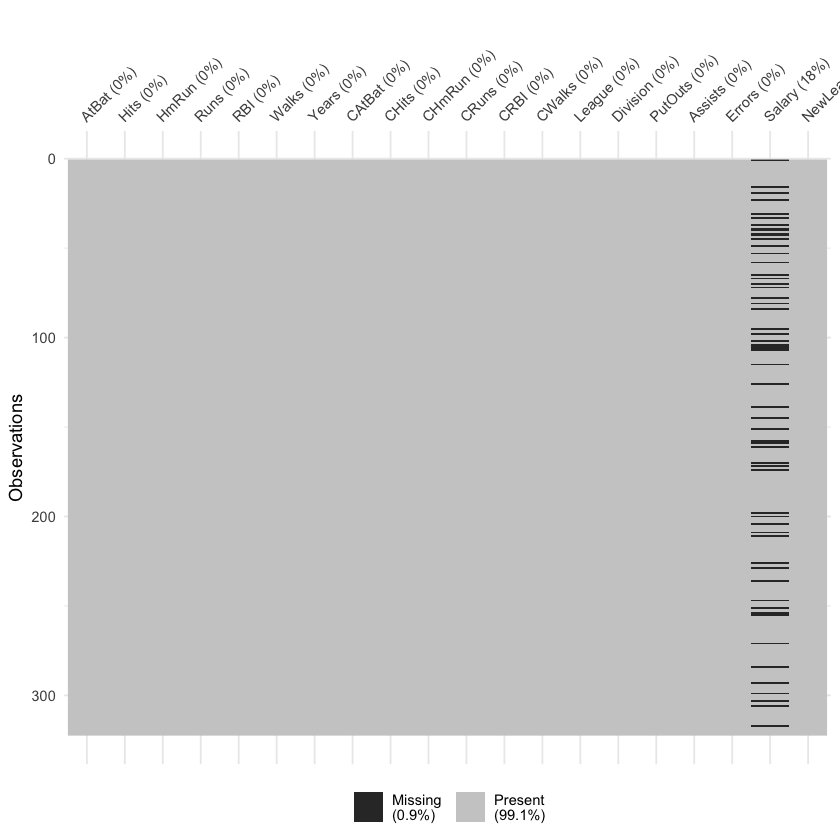

In [9]:
library(naniar)
vis_miss(Hitters)

In [10]:
print(c("CHECK NUMBER OF NA:",with(Hitters, sum(is.na(Hitters$Salary)))))


[1] "CHECK NUMBER OF NA:" "59"                 


### Best subset selection

Best subset selection is a method in statistics where all possible combinations of predictors are evaluated to identify the subset of predictors that best fits a model. It aims to find the most predictive variables while minimizing model complexity.

`Recall the algorithm`

1. Let $\mathcal{M}_0$ denote the null model, which contains no predictors.
2. This model simply predicts the sample mean for each observation.
3. For $k=1,2, \ldots p$ :
   1. (a) Fit all $\left(\begin{array}{l}p \\ k\end{array}\right)$ models that contain exactly $k$ predictors.
   2. (b) Pick the best among these $\left(\begin{array}{l}p \\ k\end{array}\right)$ models, and call it $\mathcal{M}_k$. Here best is defined as having the smallest RSS, or equivalently largest $R^2$.
4. Select a single best model from among $\mathcal{M}_0, \ldots, \mathcal{M}_p$ using cross-validated prediction error, $C_p$ (AIC), BIC, or adjusted $R^2$.
5.

In R, `regsubsets` is a function provided by the `leaps` package. It performs an exhaustive search of the best subsets of predictors for linear regression models. `regsubsets` generates models for all possible combinations of predictors and evaluates them based on a specified criterion (such as adjusted R-squared or Cp) to determine the best subset of predictors for the regression model.

In [ ]:
# RUN THE BEST SUBSET SELECTION ALGORITHM USING regsubsets
# USE Y=SALARY X=Everything else

# This code performs best subset selection for a linear regression model using the regsubsets function on the Hitters dataset,
# with Salary as the dependent variable and all other variables (.) as potential predictors. It computes various models with different
# subsets of predictors to determine the best-fitting model.

regfit.full=regsubsets(Salary~.,Hitters)

In [13]:
#THE FUNCTION SUMMARY() REPORTS THE BEST SET OF VARIABLES FOR EACH MODEL SIZE.
summary(regfit.full)


Subset selection object
Call: regsubsets.formula(Salary ~ ., Hitters)
19 Variables  (and intercept)
           Forced in Forced out
AtBat          FALSE      FALSE
Hits           FALSE      FALSE
HmRun          FALSE      FALSE
Runs           FALSE      FALSE
RBI            FALSE      FALSE
Walks          FALSE      FALSE
Years          FALSE      FALSE
CAtBat         FALSE      FALSE
CHits          FALSE      FALSE
CHmRun         FALSE      FALSE
CRuns          FALSE      FALSE
CRBI           FALSE      FALSE
CWalks         FALSE      FALSE
LeagueN        FALSE      FALSE
DivisionW      FALSE      FALSE
PutOuts        FALSE      FALSE
Assists        FALSE      FALSE
Errors         FALSE      FALSE
NewLeagueN     FALSE      FALSE
1 subsets of each size up to 8
Selection Algorithm: exhaustive
         AtBat Hits HmRun Runs RBI Walks Years CAtBat CHits CHmRun CRuns CRBI
1  ( 1 ) " "   " "  " "   " "  " " " "   " "   " "    " "   " "    " "   "*" 
2  ( 1 ) " "   "*"  " "   " "  " " " "   

Looks like it only goes up-to 8 best variables (i.e. the default for nvmax is 8).

Let's try all 19 variables, by adjusting nvmax.

In [15]:
# RUN THE BEST SUBSET SELECTION ALGORITHM USING regsubsets
# IN OUR EXAMPLE, WE HAVE N PREDICTOR VARIABLES IN THE DATA. SO, WE'LL USE NVMAX = N .
regfit.full=regsubsets(Salary~.,data=Hitters,nvmax=19)
print(regfit.full)


Subset selection object
Call: regsubsets.formula(Salary ~ ., data = Hitters, nvmax = 19)
19 Variables  (and intercept)
           Forced in Forced out
AtBat          FALSE      FALSE
Hits           FALSE      FALSE
HmRun          FALSE      FALSE
Runs           FALSE      FALSE
RBI            FALSE      FALSE
Walks          FALSE      FALSE
Years          FALSE      FALSE
CAtBat         FALSE      FALSE
CHits          FALSE      FALSE
CHmRun         FALSE      FALSE
CRuns          FALSE      FALSE
CRBI           FALSE      FALSE
CWalks         FALSE      FALSE
LeagueN        FALSE      FALSE
DivisionW      FALSE      FALSE
PutOuts        FALSE      FALSE
Assists        FALSE      FALSE
Errors         FALSE      FALSE
NewLeagueN     FALSE      FALSE
1 subsets of each size up to 19
Selection Algorithm: exhaustive


In [16]:
# PRINT RESULTS
reg.summary=summary(regfit.full)
print(class(reg.summary))
print(reg.summary)


[1] "summary.regsubsets"
Subset selection object
Call: regsubsets.formula(Salary ~ ., data = Hitters, nvmax = 19)
19 Variables  (and intercept)
           Forced in Forced out
AtBat          FALSE      FALSE
Hits           FALSE      FALSE
HmRun          FALSE      FALSE
Runs           FALSE      FALSE
RBI            FALSE      FALSE
Walks          FALSE      FALSE
Years          FALSE      FALSE
CAtBat         FALSE      FALSE
CHits          FALSE      FALSE
CHmRun         FALSE      FALSE
CRuns          FALSE      FALSE
CRBI           FALSE      FALSE
CWalks         FALSE      FALSE
LeagueN        FALSE      FALSE
DivisionW      FALSE      FALSE
PutOuts        FALSE      FALSE
Assists        FALSE      FALSE
Errors         FALSE      FALSE
NewLeagueN     FALSE      FALSE
1 subsets of each size up to 19
Selection Algorithm: exhaustive
          AtBat Hits HmRun Runs RBI Walks Years CAtBat CHits CHmRun CRuns CRBI
1  ( 1 )  " "   " "  " "   " "  " " " "   " "   " "    " "   " "    " "  

We can extract the linear fitting parameters, from the OLS fit, for the optimal subset for the different feature sub-set sizes

In [17]:
coef(regfit.full,1)
coef(regfit.full,2)
coef(regfit.full,19)

(Intercept)        CRBI 
274.5803864   0.7909536

(Intercept)        Hits        CRBI 
-47.9559022   3.3008446   0.6898994

(Intercept)        AtBat         Hits        HmRun         Runs          RBI 
 163.1035878   -1.9798729    7.5007675    4.3308829   -2.3762100   -1.0449620 
       Walks        Years       CAtBat        CHits       CHmRun        CRuns 
   6.2312863   -3.4890543   -0.1713405    0.1339910   -0.1728611    1.4543049 
        CRBI       CWalks      LeagueN    DivisionW      PutOuts      Assists 
   0.8077088   -0.8115709   62.5994230 -116.8492456    0.2818925    0.3710692 
      Errors   NewLeagueN 
  -3.3607605  -24.7623251

In [18]:
# LOOK AT AVAILABLE QUANTITIES
print(names(reg.summary))

[1] "which"  "rsq"    "rss"    "adjr2"  "cp"     "bic"    "outmat" "obj"   


In [19]:
# PRINT R^2 FOR THE 19 SUBSETS
print(length(reg.summary$rsq))
print(reg.summary$rsq)


[1] 19
 [1] 0.3214501 0.4252237 0.4514294 0.4754067 0.4908036 0.5087146 0.5141227
 [8] 0.5285569 0.5346124 0.5404950 0.5426153 0.5436302 0.5444570 0.5452164
[15] 0.5454692 0.5457656 0.5459518 0.5460945 0.5461159


Recall: Adjusted $R^2$ is a modified version of $R^2$ that penalizes model complexity by adjusting for the number of predictors.

In [20]:
# PRINT ADJUSTED R^2 FOR THE 19 SUBSETS
print(reg.summary$adjr2)
print(c("SUBSET WITH MAXIMUM adjr2=",which.max(reg.summary$adjr2)))

 [1] 0.3188503 0.4208024 0.4450753 0.4672734 0.4808971 0.4972001 0.5007849
 [8] 0.5137083 0.5180572 0.5222606 0.5225706 0.5217245 0.5206736 0.5195431
[15] 0.5178661 0.5162219 0.5144464 0.5126097 0.5106270
[1] "SUBSET WITH MAXIMUM adjr2=" "11"                        


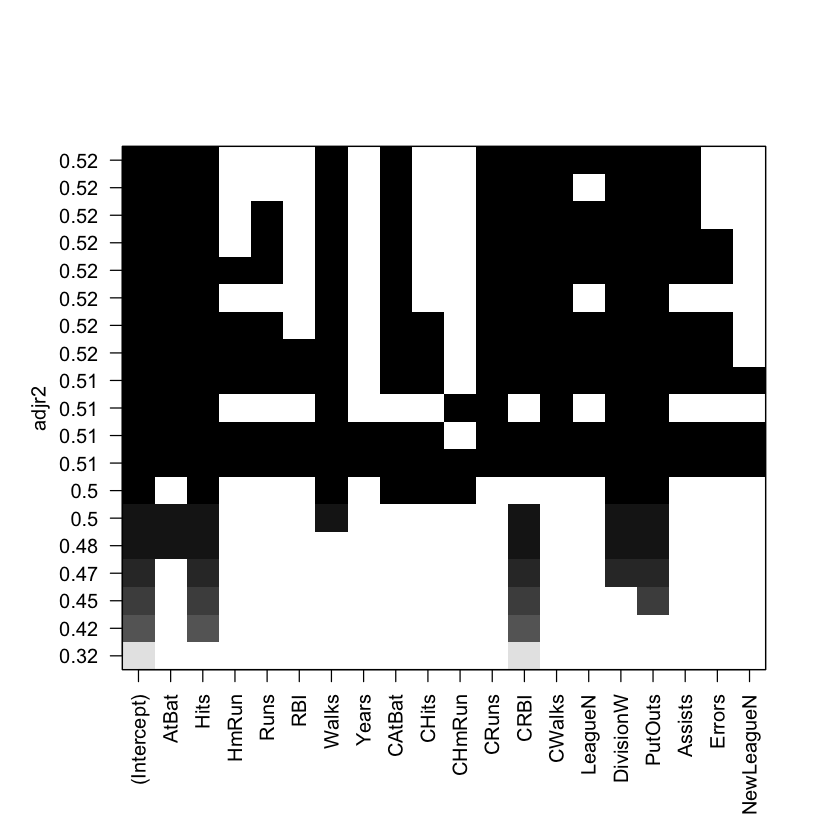

In [ ]:
# VISUALIZE adjr2 FOR ALL 19 SUBSETS (COLOR=adjr2)(TOP ROW=BEST)
# FEATURE SUBSETS CHOICES SHOWN ON X

# The code creates a plot of the adjusted R-squared values against the number of predictors for models generated by the regfit.full object.
# It helps visualize how the adjusted R-squared changes as more predictors are added to the model, providing insight into the model's complexity
# and explanatory power.

plot(regfit.full,scale="adjr2")

We can plot the various metrics, e.g. adjr2 as a function of the subset size. In an attempt to determine the optimal feature subset size

[1] "optimal feature subset-size according to adjr2:"
[2] "11"                                             


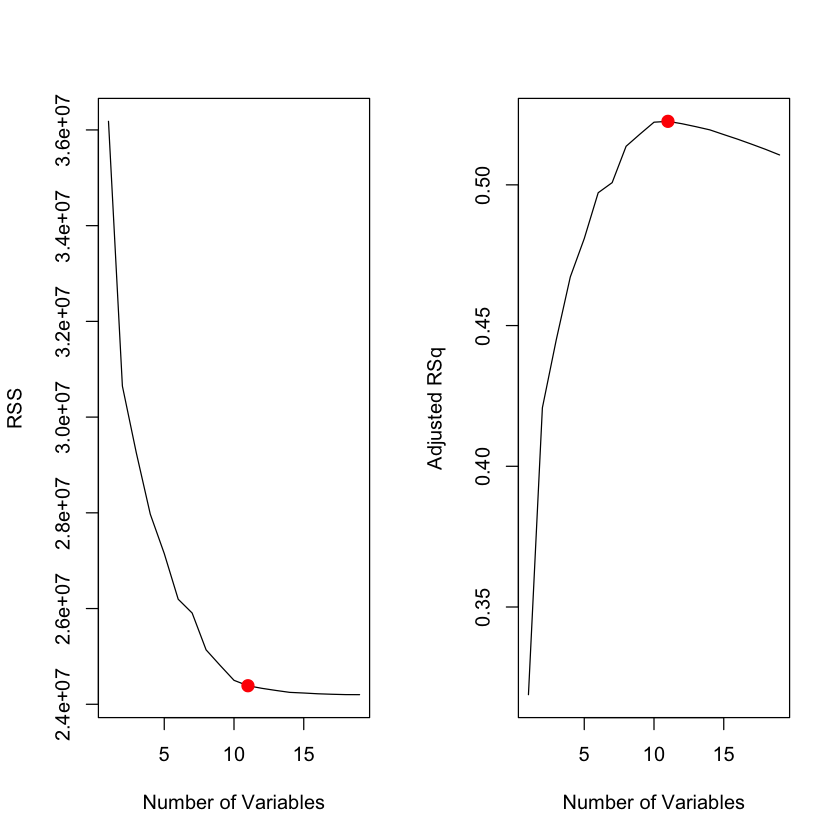

In [22]:
# GENERATE PLOT SHOWING adjr2 MAX

# Define Sub-Plots: Divides the plotting area into two sections arranged in one row and two columns (mfrow=c(1,2)), allowing for side-by-side comparison.
par(mfrow=c(1,2))

# Get Max M: Identifies the index (m) of the maximum adjusted R-squared value (adjr2) in the reg.summary object.
m=which.max(reg.summary$adjr2);
print(c("optimal feature subset-size according to adjr2:",m))

# Plot RSS: Draws a line plot of the residual sum of squares (RSS) against the number of variables.
plot(reg.summary$rss,xlab="Number of Variables",ylab="RSS",type="l")
points(m,reg.summary$rss[m], col="red",cex=2,pch=20)
plot(reg.summary$adjr2,xlab="Number of Variables",ylab="Adjusted RSq",type="l")
points(m,reg.summary$adjr2[m], col="red",cex=2,pch=20)
points(m,reg.summary$rss[m], col="red")

Alternatively we can also

[1] "optimal feature subset-size according to cp:"
[2] "10"                                          


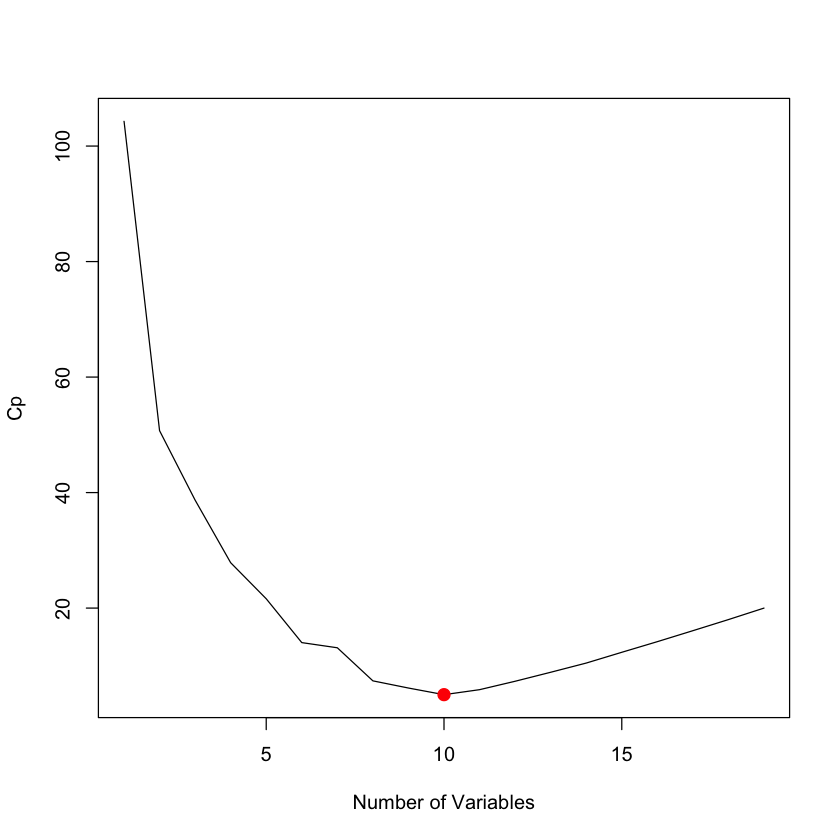

In [23]:
# PLOT MIN CP POINT
plot(reg.summary$cp,xlab="Number of Variables",ylab="Cp",type='l')
m=which.min(reg.summary$cp)
print(c("optimal feature subset-size according to cp:",m))
points(m,reg.summary$cp[10],col="red",cex=2,pch=20)

[1] "optimal feature subset-size according to BIC:"
[2] "6"                                            


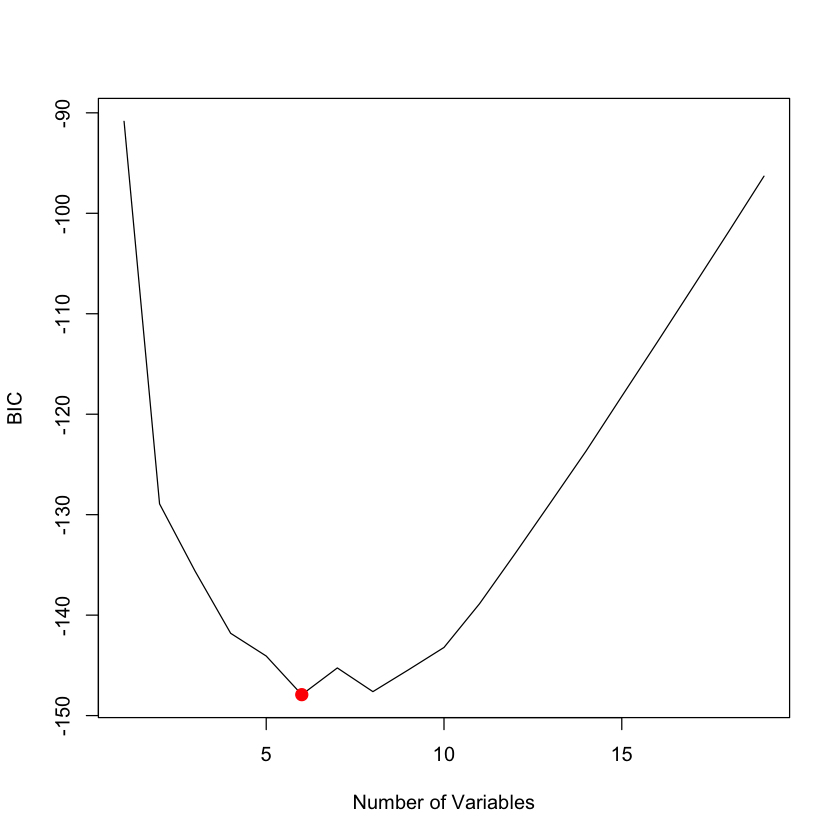

In [24]:
# PLOT MIN BIC POINT
m=which.min(reg.summary$bic)
print(c("optimal feature subset-size according to BIC:",m))
plot(reg.summary$bic,xlab="Number of Variables",ylab="BIC",type='l')
points(m,reg.summary$bic[6],col="red",cex=2,pch=20)

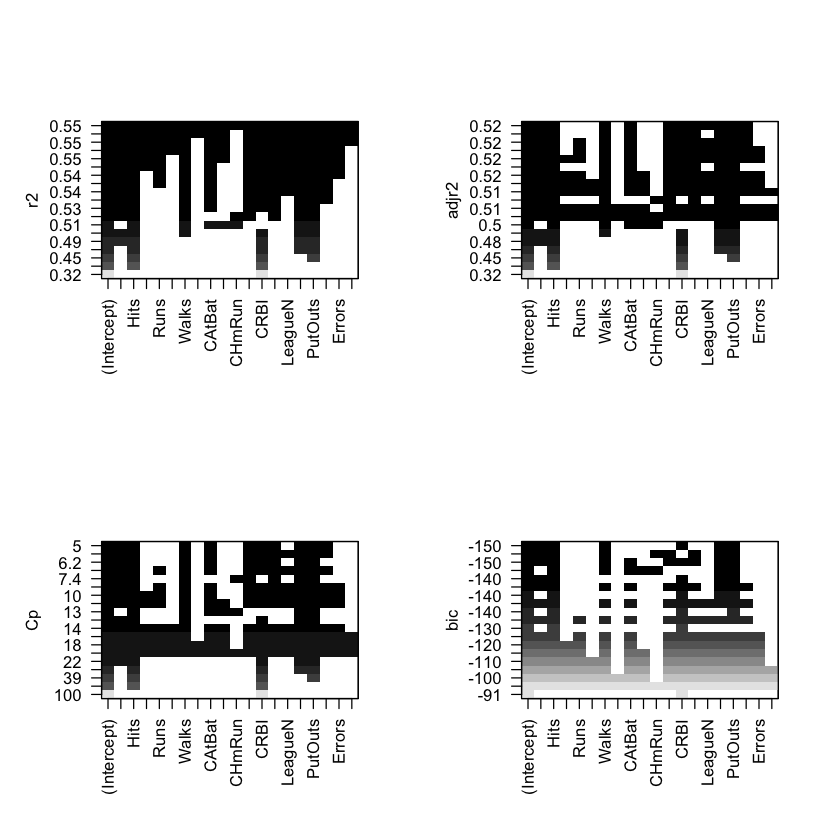

In [25]:
# GENERATE MATRIX PLOTS FOR DIFFERENT METRICS

# sets up a 2x2 plotting layout using par(mfrow=c(2,2)), allowing for four plots to be displayed simultaneously.

par(mfrow=c(2,2))
plot(regfit.full,scale="r2")
plot(regfit.full,scale="adjr2")
plot(regfit.full,scale="Cp")
plot(regfit.full,scale="bic")

In [26]:
# PRINT FITTING PARAMETERS FOR 11TH SUBSET
print(coef(regfit.full,11))

 (Intercept)        AtBat         Hits        Walks       CAtBat        CRuns 
 135.7512195   -2.1277482    6.9236994    5.6202755   -0.1389914    1.4553310 
        CRBI       CWalks      LeagueN    DivisionW      PutOuts      Assists 
   0.7852528   -0.8228559   43.1116152 -111.1460252    0.2894087    0.2688277 


### Forward and Backward Stepwise Selection

`Recall` the following overviews of these methods

`Forward selection` is a method in regression analysis where predictors are added iteratively to a model. It starts with an empty model and systematically adds variables based on their individual significance, evaluating each addition's impact on model fit. This process continues until no additional variables significantly improve the model's performance.

`Backward selection` is a regression technique where all predictors are initially included in the model, then variables are removed one by one based on their lack of significance. It systematically evaluates each variable's contribution to model fit, eliminating the least significant ones until the optimal subset remains.


In [27]:
# This code utilizes the `regsubsets` function in R to perform forward selection for a linear regression model. It selects predictors from the `Hitters` dataset to predict `Salary`, considering up to 19 variables (`nvmax=19`) in a forward stepwise manner.

regfit.fwd=regsubsets(Salary~.,data=Hitters,nvmax=19,method="forward")

In [28]:
summary(regfit.fwd)

Subset selection object
Call: regsubsets.formula(Salary ~ ., data = Hitters, nvmax = 19, method = "forward")
19 Variables  (and intercept)
           Forced in Forced out
AtBat          FALSE      FALSE
Hits           FALSE      FALSE
HmRun          FALSE      FALSE
Runs           FALSE      FALSE
RBI            FALSE      FALSE
Walks          FALSE      FALSE
Years          FALSE      FALSE
CAtBat         FALSE      FALSE
CHits          FALSE      FALSE
CHmRun         FALSE      FALSE
CRuns          FALSE      FALSE
CRBI           FALSE      FALSE
CWalks         FALSE      FALSE
LeagueN        FALSE      FALSE
DivisionW      FALSE      FALSE
PutOuts        FALSE      FALSE
Assists        FALSE      FALSE
Errors         FALSE      FALSE
NewLeagueN     FALSE      FALSE
1 subsets of each size up to 19
Selection Algorithm: forward
          AtBat Hits HmRun Runs RBI Walks Years CAtBat CHits CHmRun CRuns CRBI
1  ( 1 )  " "   " "  " "   " "  " " " "   " "   " "    " "   " "    " "   "*" 
2 

Now lets try again with backward step-wise selection

In [29]:
regfit.bwd=regsubsets(Salary~.,data=Hitters,nvmax=19,method="backward")

In [30]:
summary(regfit.bwd)

Subset selection object
Call: regsubsets.formula(Salary ~ ., data = Hitters, nvmax = 19, method = "backward")
19 Variables  (and intercept)
           Forced in Forced out
AtBat          FALSE      FALSE
Hits           FALSE      FALSE
HmRun          FALSE      FALSE
Runs           FALSE      FALSE
RBI            FALSE      FALSE
Walks          FALSE      FALSE
Years          FALSE      FALSE
CAtBat         FALSE      FALSE
CHits          FALSE      FALSE
CHmRun         FALSE      FALSE
CRuns          FALSE      FALSE
CRBI           FALSE      FALSE
CWalks         FALSE      FALSE
LeagueN        FALSE      FALSE
DivisionW      FALSE      FALSE
PutOuts        FALSE      FALSE
Assists        FALSE      FALSE
Errors         FALSE      FALSE
NewLeagueN     FALSE      FALSE
1 subsets of each size up to 19
Selection Algorithm: backward
          AtBat Hits HmRun Runs RBI Walks Years CAtBat CHits CHmRun CRuns CRBI
1  ( 1 )  " "   " "  " "   " "  " " " "   " "   " "    " "   " "    "*"   " " 


Lets compare the fitting parameters for the different methods with the feature subset of size 7

In [31]:
print(coef(regfit.full,7))
print(coef(regfit.fwd,7))
print(coef(regfit.bwd,7))

 (Intercept)         Hits        Walks       CAtBat        CHits       CHmRun 
  79.4509472    1.2833513    3.2274264   -0.3752350    1.4957073    1.4420538 
   DivisionW      PutOuts 
-129.9866432    0.2366813 
 (Intercept)        AtBat         Hits        Walks         CRBI       CWalks 
 109.7873062   -1.9588851    7.4498772    4.9131401    0.8537622   -0.3053070 
   DivisionW      PutOuts 
-127.1223928    0.2533404 
 (Intercept)        AtBat         Hits        Walks        CRuns       CWalks 
 105.6487488   -1.9762838    6.7574914    6.0558691    1.1293095   -0.7163346 
   DivisionW      PutOuts 
-116.1692169    0.3028847 


### Cross validation: validation set approach

`Choosing Among Models`

In order to use the `validation set approach`, we begin by splitting the observations into a training set and a test set.

We do this by creating a random vector, train, of elements equal to TRUE if the corresponding observation is in the training set, and FALSE otherwise.

The vector test has a TRUE if the observation is in the test set, and a FALSE otherwise.

Note the ! in the command to create test causes TRUEs to be switched to FALSEs and vice versa.

We also set a random seed so that the user will obtain the same training set/test set split.

In [62]:
Hitters = na.omit(Hitters)

In [63]:
set.seed(1)
# Generate a random sample of logical values (TRUE or FALSE)
# The sample size is the number of rows in the 'Hitters' dataset
# The 'rep = TRUE' argument specifies that sampling is done with replacement
train=sample(c(TRUE,FALSE), nrow(Hitters),rep=TRUE)

# Print fraction of dataset in training set
# print(nrow(Hitters)) # print number of rows in df
# print(train)
print(sum(as.integer(train))/nrow(Hitters))

[1] 0.5095057


In [64]:
test=(!train)
# print(test)
print(sum(as.integer(test))/nrow(Hitters))

[1] 0.4904943


Now, we apply regsubsets() to the training set in order to perform best subset selection.

Notice that we subset the Hitters data frame directly in the call in order to access only the training subset of the data, using the expression Hitters[train,].

In [65]:
regfit.best=regsubsets(Salary~.,data=Hitters[train,],nvmax=19)

We now compute the validation set error for the best model of each model size.

We first make a model matrix from the test data.

The model.matrix() function is used in many regression packages for building an “X” matrix from data.


In [66]:
print(head(Hitters[test,]))

                  AtBat Hits HmRun Runs RBI Walks Years CAtBat CHits CHmRun
-Alvin Davis        479  130    18   66  72    76     3   1624   457     63
-Alfredo Griffin    594  169     4   74  51    35    11   4408  1133     19
-Andre Thornton     401   92    17   49  66    65    13   5206  1332    253
-Alan Trammell      574  159    21  107  75    59    10   4631  1300     90
-Buddy Biancalana   190   46     2   24   8    15     5    479   102      5
-Bruce Bochy        127   32     8   16  22    14     8    727   180     24
                  CRuns CRBI CWalks League Division PutOuts Assists Errors
-Alvin Davis        224  266    263      A        W     880      82     14
-Alfredo Griffin    501  336    194      A        W     282     421     25
-Andre Thornton     784  890    866      A        E       0       0      0
-Alan Trammell      702  504    488      A        E     238     445     22
-Buddy Biancalana    65   23     39      A        W     102     177     16
-Bruce Bochy      

In [67]:
# convert to test model matrix
test.mat=model.matrix(Salary~.,data=Hitters[test,])
print(head(test.mat))

                  (Intercept) AtBat Hits HmRun Runs RBI Walks Years CAtBat
-Alvin Davis                1   479  130    18   66  72    76     3   1624
-Alfredo Griffin            1   594  169     4   74  51    35    11   4408
-Andre Thornton             1   401   92    17   49  66    65    13   5206
-Alan Trammell              1   574  159    21  107  75    59    10   4631
-Buddy Biancalana           1   190   46     2   24   8    15     5    479
-Bruce Bochy                1   127   32     8   16  22    14     8    727
                  CHits CHmRun CRuns CRBI CWalks LeagueN DivisionW PutOuts
-Alvin Davis        457     63   224  266    263       0         1     880
-Alfredo Griffin   1133     19   501  336    194       0         1     282
-Andre Thornton    1332    253   784  890    866       0         0       0
-Alan Trammell     1300     90   702  504    488       0         0     238
-Buddy Biancalana   102      5    65   23     39       0         1     102
-Bruce Bochy        180  

Now we run a loop, and for each size i, we extract the coefficients from regfit.best for the best model of that size, multiply them into the appropriate columns of the test model matrix to form the predictions, and compute the test MSE.

In [68]:
# Initialize a vector to store validation errors, with length 19
val.errors = rep(NA, 19)

# Iterate through 19 iterations
for (i in 1:19) {
  # Extract coefficients for the 'i-th' subset from the 'regfit.best' object
  coefi = coef(regfit.best, id = i)

  # Select the predictor variables based on the coefficients
  # and predict using the 'test.mat' data
  pred = test.mat[, names(coefi)] %*% coefi

  # Calculate the validation error as mean squared error
  # by comparing the predicted values with the actual 'Salary' values
  val.errors[i] = mean((Hitters$Salary[test] - pred)^2)
}

We find that the best model is the one that contains ten variables.

In [69]:
print("------------------")
print(val.errors)
print("------------------")
m=which.min(val.errors) #m=10
print(coef(regfit.best,m))

[1] "------------------"
 [1] 164377.3 144405.5 152175.7 145198.4 137902.1 139175.7 126849.0 136191.4
 [9] 132889.6 135434.9 136963.3 140694.9 140690.9 141951.2 141508.2 142164.4
[17] 141767.4 142339.6 142238.2
[1] "------------------"
 (Intercept)        AtBat         Hits        Walks        CRuns       CWalks 
  67.1085369   -2.1462987    7.0149547    8.0716640    1.2425113   -0.8337844 
   DivisionW      PutOuts 
-118.4364998    0.2526925 


This was a little tedious, partly because there is no predict() method for regsubsets().

Since we will be using this function again, we can capture our results from above and write our own predict method.

In [71]:
# Define a function called predict.regsubsets
predict.regsubsets = function(object, newdata, id, ...) {

  # Extract the formula used to fit the model
  form = as.formula(object$call[[2]])

  # Create the model matrix for the new data based on the formula used in the model fitting
  mat = model.matrix(form, newdata)

  # Obtain the coefficients for the specified model subset (id)
  coefi = coef(object, id = id)

  # Extract the names of the predictor variables
  xvars = names(coefi)

  # Multiply the subset of the model matrix with the corresponding coefficients
  # This calculates the predicted values for the new data
  mat[, xvars] %*% coefi
}


Our function pretty much mimics what we did above.

Finally, we perform best subset selection on the full data set, and select the best ten-variable model.


In [72]:
regfit.best=regsubsets(Salary~.,data=Hitters,nvmax=19)
print(coef(regfit.best,10))

 (Intercept)        AtBat         Hits        Walks       CAtBat        CRuns 
 162.5354420   -2.1686501    6.9180175    5.7732246   -0.1300798    1.4082490 
        CRBI       CWalks    DivisionW      PutOuts      Assists 
   0.7743122   -0.8308264 -112.3800575    0.2973726    0.2831680 


In fact, we see that the best ten-variable model on the full data set has a different set of variables than the best ten-variable model on the training set.
### Cross validation: K-Fold

We now try to choose among the models of different sizes using cross-validation.

we must perform best subset selection within each of the k training sets.

Despite this, we see that with its clever subsetting syntax, R makes this job quite easy.

First, we create a vector that allocates each observation to one of k = 10 folds, and we create a matrix in which we will store the results.

In [73]:
# Set the number of folds for cross-validation
k = 10

# Set the seed for reproducibility
set.seed(1)

# Create a vector of 'k' folds, each fold representing a subset of observations
# from 1 to 'k', with replacement
folds = sample(1:k, nrow(Hitters), replace = TRUE)

# Create a matrix to store cross-validation errors
# Rows correspond to folds, columns correspond to different subsets of variables (1 to 19)
cv.errors = matrix(NA, k, 19, dimnames = list(NULL, paste(1:19)))

Now we write a for loop that performs cross-validation.

In the jth fold, the elements of folds that equal j are in the test set, and the remainder are in the training set.

We make our predictions for each model size (using our new predict() method), compute the test errors on the appropriate subset, and store them in the appropriate slot in the matrix cv.errors.


In [74]:
# Loop over each fold for cross-validation
for (j in 1:k) {
  # Fit regression models using subsets of predictors
  # Leave out the 'j-th' fold for validation
  best.fit = regsubsets(Salary ~ ., data = Hitters[folds != j, ], nvmax = 19)

  # Loop over each subset size (1 to 19)
  for (i in 1:19) {
    # Make predictions using the 'i-th' subset from the 'best.fit' model
    pred = predict(best.fit, Hitters[folds == j, ], id = i)

    # Calculate the mean squared error for the current fold and subset
    cv.errors[j, i] = mean((Hitters$Salary[folds == j] - pred)^2)
  }
}

This has given us a 10×19 matrix, of which the (i, j)th element corresponds to the test MSE for the ith cross-validation fold for the best j-variable model.

We use the apply() function to average over the columns of this matrix in order to obtain a vector for which the jth element is the cross- validation error for the j-variable model.

       1        2        3        4        5        6        7        8 
149821.1 130922.0 139127.0 131028.8 131050.2 119538.6 124286.1 113580.0 
       9       10       11       12       13       14       15       16 
115556.5 112216.7 113251.2 115755.9 117820.8 119481.2 120121.6 120074.3 
      17       18       19 
120084.8 120085.8 120403.5 


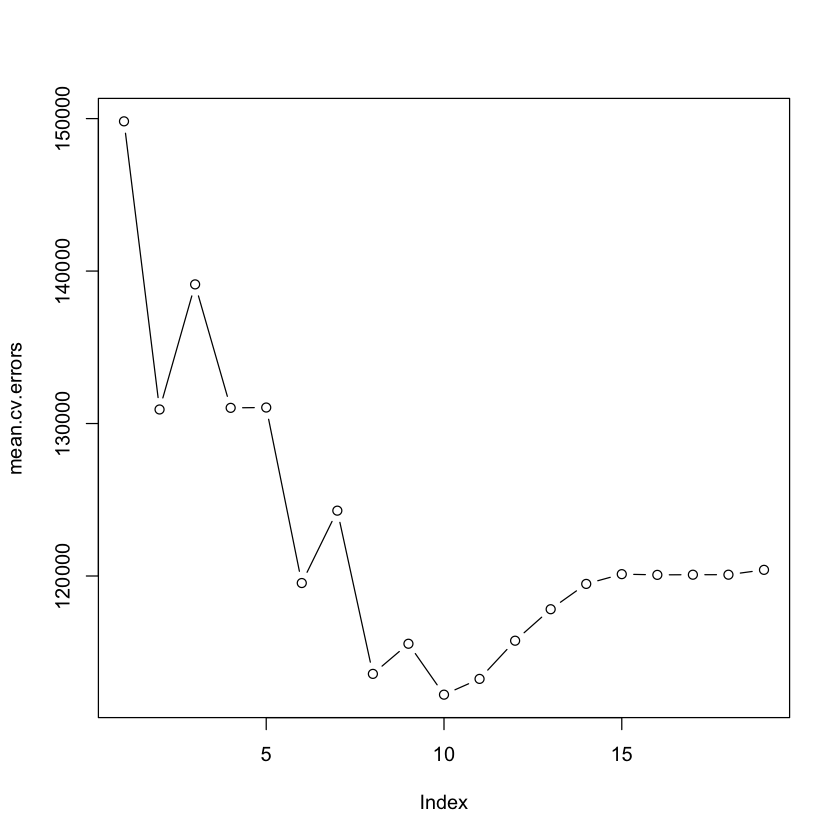

In [79]:
 # Calculate the mean cross-validation errors across all folds for each subset size
mean.cv.errors = apply(cv.errors, 2, mean)

# Print the mean cross-validation errors
print(mean.cv.errors)

# Set the plotting layout to a single panel
par(mfrow = c(1, 1))

# Plot the mean cross-validation errors
plot(mean.cv.errors, type = 'b')

We see that cross-validation selects an 10-variable model.

We now perform best subset selection on the full data set in order to obtain the 10-variable model.


In [80]:
reg.best=regsubsets(Salary~.,data=Hitters, nvmax=19)
print(coef(reg.best,10))

 (Intercept)        AtBat         Hits        Walks       CAtBat        CRuns 
 162.5354420   -2.1686501    6.9180175    5.7732246   -0.1300798    1.4082490 
        CRBI       CWalks    DivisionW      PutOuts      Assists 
   0.7743122   -0.8308264 -112.3800575    0.2973726    0.2831680 


## Example: Fertility Data

Predicting fertility score on the basis of socio-economic indicators.

In [81]:
# Load the data
data("swiss")
# Inspect the data
sample_n(swiss, 3)

,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
Nyone,56.6,50.9,22,12,15.14,16.7
Moutier,85.8,36.5,12,7,33.77,20.3
Echallens,68.3,72.6,18,2,24.20,21.2


(a). Computing best subsets regression.

In our example, we have only 5 predictor variables in the data. So, we’ll use nvmax = 5.

In [82]:
models <- regsubsets(Fertility~., data = swiss, nvmax = 5)
summary(models)

Subset selection object
Call: regsubsets.formula(Fertility ~ ., data = swiss, nvmax = 5)
5 Variables  (and intercept)
                 Forced in Forced out
Agriculture          FALSE      FALSE
Examination          FALSE      FALSE
Education            FALSE      FALSE
Catholic             FALSE      FALSE
Infant.Mortality     FALSE      FALSE
1 subsets of each size up to 5
Selection Algorithm: exhaustive
         Agriculture Examination Education Catholic Infant.Mortality
1  ( 1 ) " "         " "         "*"       " "      " "             
2  ( 1 ) " "         " "         "*"       "*"      " "             
3  ( 1 ) " "         " "         "*"       "*"      "*"             
4  ( 1 ) "*"         " "         "*"       "*"      "*"             
5  ( 1 ) "*"         "*"         "*"       "*"      "*"             

It can be seen that the best 2-variables model contains only Education and Catholic variables

$(Fertility \sim Education + Catholic)$.

The best three-variable model is

$(Fertility \sim Education + Catholic + Infant.mortality)$, and so forth.

A natural question is: which of these best models should we finally choose for our predictive analytics?

(c) Choosing the optimal model.

In [83]:
res.sum <- summary(models)

data.frame(
  Adj.R2 = which.max(res.sum$adjr2),
  CP = which.min(res.sum$cp),
  BIC = which.min(res.sum$bic)
)

Adj.R2,CP,BIC
<int>,<int>,<int>
5,4,4


Here, adjusted R2 tells us that the best model is the one with all the 5 predictor variables. However, using the BIC and Cp criteria, we should go for the model with 4 variables.

Note also that the adjusted R2, BIC and Cp are calculated on the training data that have been used to fit the model. This means that, the model selection, using these metrics, is possibly subject to overfitting and may not perform as well when applied to new data.

A more rigorous approach is to select a models based on the prediction error computed on a new test data using k-fold cross-validation

(d). K-fold cross-validation

(i) get_model_formula(), allowing to access easily the formula of the models returned by the function regsubsets().

In [84]:
# id: model id
# object: regsubsets object
# data: data used to fit regsubsets
# outcome: outcome variable
get_model_formula <- function(id, object, outcome){
  # get models data
  models <- summary(object)$which[id,-1]
  # Get outcome variable
  #form <- as.formula(object$call[[2]])
  #outcome <- all.vars(form)[1]
  # Get model predictors
  predictors <- names(which(models == TRUE))
  predictors <- paste(predictors, collapse = "+")
  # Build model formula
  as.formula(paste0(outcome, "~", predictors))
}

For example to have the best 3-variable model formula;

In [85]:
get_model_formula(3, models, "Fertility")


Fertility ~ Education + Catholic + Infant.Mortality
<environment: 0x13f58f808>

(ii) get_cv_error(), to get the cross-validation (CV) error for a given model:

In [86]:
get_cv_error <- function(model.formula, data){
  set.seed(1)
  train.control <- trainControl(method = "cv", number = 5)
  cv <- train(model.formula, data = data, method = "lm",
              trControl = train.control)
  cv$results$RMSE
}

Finally, use the above defined helper functions to compute the prediction error of the different best models returned by the regsubsets() function:


In [87]:
# Compute cross-validation error
model.ids <- 1:5
cv.errors <-  map(model.ids, get_model_formula, models, "Fertility") %>%
  map(get_cv_error, data = swiss) %>%
  unlist()
cv.errors

# Select the model that minimize the CV error
which.min(cv.errors)

[1] 9.464156 8.517433 7.855267 7.601072 7.736328

[1] 4

It can be seen that the model with 4 variables is the best model. It has the lower prediction error.

The regression coefficients of this model can be extracted as follow:

In [88]:
coef(models, 4)

(Intercept)      Agriculture        Education         Catholic 
      62.1013116       -0.1546175       -0.9802638        0.1246664 
Infant.Mortality 
       1.0784422

# Part 2: Lab Assignment

## Question 1: Model Selection Criteria on the Full Training Set

Using **Best Subset Selection** with `nvmax = 19` (i.e., all predictors considered):

### (a) Fit the Models
1. Fit best subset models for all subset sizes from 1 to 19 predictors.
2. Extract the following metrics for each model size:
   * Bayesian Information Criterion (BIC)
   * Mallow’s Cp
   * Adjusted ( R^2 )

In [89]:
# remove the missing values of Hitters dataset
Hitters = na.omit(Hitters)

In [95]:
# fit the models for all subset
regfit.full=regsubsets(Salary~.,Hitters, nvmax =19, method='exhaustive')
summary(regfit.full)

Subset selection object
Call: regsubsets.formula(Salary ~ ., Hitters, nvmax = 19, method = "exhaustive")
19 Variables  (and intercept)
           Forced in Forced out
AtBat          FALSE      FALSE
Hits           FALSE      FALSE
HmRun          FALSE      FALSE
Runs           FALSE      FALSE
RBI            FALSE      FALSE
Walks          FALSE      FALSE
Years          FALSE      FALSE
CAtBat         FALSE      FALSE
CHits          FALSE      FALSE
CHmRun         FALSE      FALSE
CRuns          FALSE      FALSE
CRBI           FALSE      FALSE
CWalks         FALSE      FALSE
LeagueN        FALSE      FALSE
DivisionW      FALSE      FALSE
PutOuts        FALSE      FALSE
Assists        FALSE      FALSE
Errors         FALSE      FALSE
NewLeagueN     FALSE      FALSE
1 subsets of each size up to 19
Selection Algorithm: exhaustive
          AtBat Hits HmRun Runs RBI Walks Years CAtBat CHits CHmRun CRuns CRBI
1  ( 1 )  " "   " "  " "   " "  " " " "   " "   " "    " "   " "    " "   "*" 
2  

In [93]:
names(summary(regfit.full))

[1] "which"  "rsq"    "rss"    "adjr2"  "cp"     "bic"    "outmat" "obj"

In [99]:
# Extract BIC
print('BIC for all models:')
summary(regfit.full)$bic
# Extract Mallow’s Cp
print('Mallows CP for all models:')
summary(regfit.full)$cp
# Extract Adjusted R^2
print('Adjusted R^2 for all models:')
summary(regfit.full)$adjr2

[1] "BIC for all models:"


[1]  -90.84637 -128.92622 -135.62693 -141.80892 -144.07143 -147.91690
 [7] -145.25594 -147.61525 -145.44316 -143.21651 -138.86077 -133.87283
[13] -128.77759 -123.64420 -118.21832 -112.81768 -107.35339 -101.86391
[19]  -96.30412

[1] "Mallows CP for all models:"


[1] 104.281319  50.723090  38.693127  27.856220  21.613011  14.023870
 [7]  13.128474   7.400719   6.158685   5.009317   5.874113   7.330766
[13]   8.888112  10.481576  12.346193  14.187546  16.087831  18.011425
[19]  20.000000

[1] "Adjusted R^2 for all models:"


[1] 0.3188503 0.4208024 0.4450753 0.4672734 0.4808971 0.4972001 0.5007849
 [8] 0.5137083 0.5180572 0.5222606 0.5225706 0.5217245 0.5206736 0.5195431
[15] 0.5178661 0.5162219 0.5144464 0.5126097 0.5106270

### (b) Visualization

Create **three separate plots**, each showing the metric as a function of model size:

1. BIC vs. Number of Predictors
2. Mallow’s Cp vs. Number of Predictors
3. Adjusted ( R^2 ) vs. Number of Predictors


For each plot:

* Clearly label axes.
* Highlight the optimal model size (minimum for BIC and Cp; maximum for Adjusted ( R^2 )).
* Use consistent formatting across plots.


### (c) Interpretation

Answer the following questions clearly and concisely:

1. What model size is selected by each metric?
2. Do the three criteria select the same model size?
3. If they differ, explain **why** this may occur, referencing how each metric penalizes model complexity.
4. Based solely on these training-set metrics, which model would you choose? Justify your answer.


Your explanation should demonstrate understanding of:

* Overfitting
* Bias–variance tradeoff
* Penalty structure of BIC vs Cp vs Adjusted ( R^2 )

## Question 2: Cross-Validation vs Training-Based Selection

The criteria in Question 1 are computed using the full training data. In this question, you will evaluate models using cross-validation.

### (a) Validation Set Approach

1. Randomly split the dataset into training and test sets.
2. Perform best subset selection using only the training set.
3. Compute test Mean Squared Error (MSE) for each model size.
4. Identify the model size that minimizes test MSE.
5. Compare this selected model size with those selected in Question 1.

### (b) K-Fold Cross-Validation (k = 10)

1. Perform 10-fold cross-validation.
2. Compute the average test MSE for each model size.
3. Plot cross-validated MSE vs. model size.
4. Identify the optimal model size.

### (c) Comparative Analysis

Answer the following:

1. Does cross-validation select the same model as BIC/Cp/Adjusted ( R^2 )?
2. If not, why might they differ?
3. Which approach do you believe provides the most reliable model selection in this context?